K Mean Clastering 

In [24]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np 
%matplotlib inline 


In [25]:
x,y= make_blobs(n_samples=1000 , centers=3 , n_features=2 , random_state=23)

In [26]:
x.shape

(1000, 2)

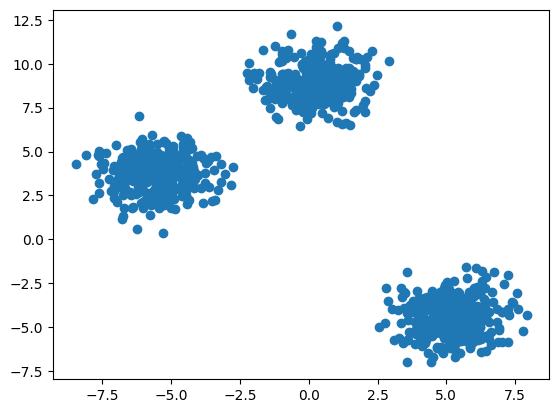

In [27]:
plt.scatter(x[:,0],x[:,1])

In [28]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test  = train_test_split( x,y, test_size=0.33,random_state =42 )

In [29]:
from sklearn.cluster import KMeans

In [30]:
# Manual Process 
# Elbow Method to select the k value 

wcss=[]
for k in range (1,11):
    Kmean = KMeans(n_clusters=k , init='k-means++')
    Kmean.fit(x_train)
    wcss.append(Kmean.inertia_)

In [31]:
wcss

[34827.57682552023,
 7935.437286145421,
 1319.2730531585605,
 1140.4677884655127,
 991.8899785187886,
 856.606549650504,
 769.5264547980976,
 669.2243953620581,
 628.1517411276989,
 546.5806590489453]

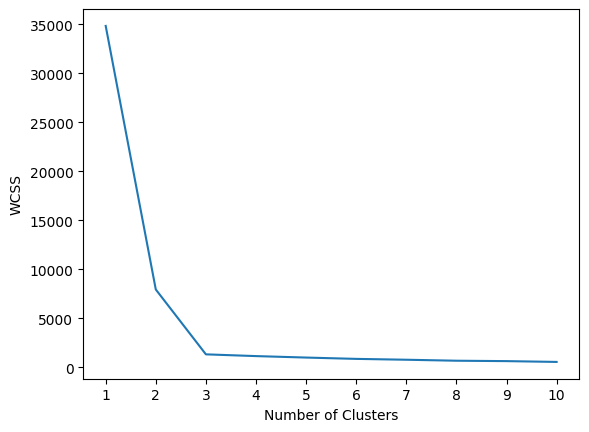

In [ ]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [33]:
Kmean =KMeans(n_clusters=3 , init="k-means++")
y_lables = Kmean.fit_predict(x_train)

In [38]:
y_test_label =Kmean.predict(x_test)
y_test_label

array([2, 2, 2, 1, 0, 2, 1, 1, 0, 1, 2, 2, 0, 1, 2, 1, 1, 2, 0, 2, 2, 2,
       1, 2, 2, 1, 0, 2, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 2, 0, 0, 2,
       1, 0, 1, 2, 2, 1, 0, 2, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 1,
       1, 2, 0, 0, 2, 2, 0, 1, 1, 2, 1, 1, 2, 2, 0, 0, 1, 0, 1, 1, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 1, 2, 1, 0, 1, 1, 0, 2, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 1, 1, 0, 2, 0, 1, 0, 2,
       2, 0, 1, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 2, 0, 0, 2,
       2, 0, 2, 2, 1, 1, 2, 2, 1, 1, 0, 2, 1, 1, 2, 2, 2, 0, 2, 2, 0, 0,
       0, 1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 0, 1, 2, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 2, 2, 1, 2, 1, 0, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0,
       1, 2, 0, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 1, 0, 0, 1, 2, 1, 2, 0, 2,
       2, 0, 2, 1, 2, 2, 0, 2, 1, 1, 1, 2, 1, 0, 2, 2, 1, 2, 1, 1, 1, 2,
       1, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 1, 1, 2, 2, 1, 1,
       2, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 1, 2,

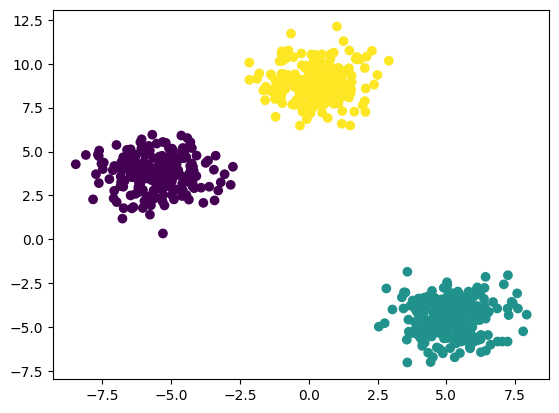

In [35]:
plt.scatter(x_train[:,0],x_train[:,1] , c=y_lables)

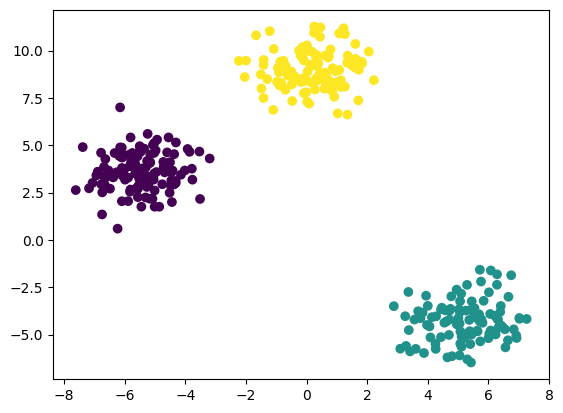

In [39]:
plt.scatter(x_test[:,0],x_test[:,1] , c=y_test_label)

In [41]:
pip install kneed

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
from kneed import KneeLocator

In [45]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [46]:
## performance  metrics 
from sklearn.metrics import silhouette_score


In [49]:
silhouette_coefficient=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficient.append(score)

In [50]:
silhouette_coefficient

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797673),
 np.float64(0.6357733426488265),
 np.float64(0.4763485724139249),
 np.float64(0.4867341284238115),
 np.float64(0.3183601194018182),
 np.float64(0.3491309101403022),
 np.float64(0.31679591346483915),
 np.float64(0.33996196989109406)]

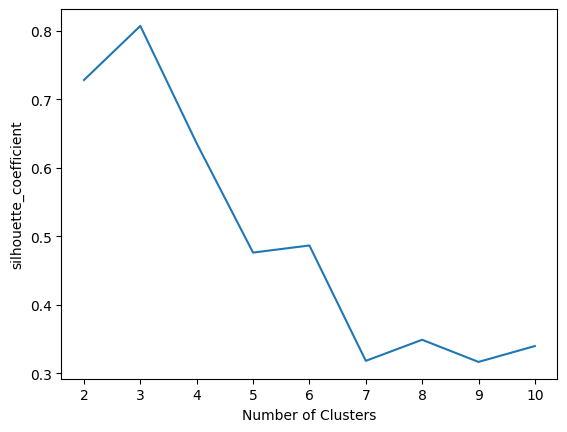

In [52]:
plt.plot(range(2,11),silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("silhouette_coefficient")
plt.show()